In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
maternusherold_pred_maintanance_data_path = kagglehub.dataset_download('maternusherold/pred-maintanance-data')

print('Data source import complete.')


Data source import complete.


# Introduction.
The notebook aims to learn building RNN and LSTM networks for time-dependent variables.
While I was looking to learn building an LSTM like networks for continuous/time-dependent variables, I came across a very nice notebook ([link](https://github.com/Azure/lstms_for_predictive_maintenance/blob/master/Deep%20Learning%20Basics%20for%20Predictive%20Maintenance.ipynb)). In this notebook most of the approach is taken from the mentioned notebook link and credit goes to original authors. <br>

Problem statement: Predict if an engine will fail within a particular cycle, given its history of cycles and sensory data. <br>

* Aircraft are very sensitive to the faults in their engines.
* Because of this, it is imperative to keep them in good condition for the safety of the passengers.
* Aircraft are very expensive and so is their maintenance.
* But at the same time, we do not want to overdo the maintenance aspect.
* If we do not detect a fault in time, it might become too expensive to maintain/repair the engines, or they might have to be replaced


The content of the notebooks are as below.
1. importing libs<br>
2. Load the Dataset <br>
3. Data Preprocessing<br>
    3.1. Generating the classification target variable<br>
    3.2. Normalizing the data set<br>
4.Exploratory Data Analysis - EDA<br>
5. Generating Input Sequence<br>
6. RNN Models<br>
    6.1 Simple RNN [1 Feature] <br>
    6.2 Simple RNN [25 Features] <br>
    6.3  Bi-Directional RNN [25 Features] <br>
7. Model Building with LSTM <br>
8. References

![image.png](attachment:fe04186a-4eaa-4cc2-9957-123070b8a8a9.png)

# 1. Importing libs

In [ ]:
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU

In [ ]:
# We will set the seed for reproducibility.
np.random.seed(1234)
PYTHONHASHSEED = 0

# 2. Load the Dataset

In [ ]:
# Training data where the last cycle is the failure point for the engines
train_df = pd.read_csv('/kaggle/input/pred-maintanance-data/PM_train.txt', sep=" ", header=None)

# Test data where the failure point is not given for the engines
test_df = pd.read_csv('/kaggle/input/pred-maintanance-data/PM_test.txt', sep=" ", header=None)

# We wil print some rows of the train data
train_df.head(100)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,96,-0.0034,0.0001,100.0,518.67,642.19,1584.07,1395.16,14.62,...,8130.69,8.4311,0.03,392,2388,100.0,38.88,23.3255,NaN,NaN
96,1,97,0.0035,-0.0003,100.0,518.67,642.07,1595.77,1407.81,14.62,...,8128.74,8.4105,0.03,392,2388,100.0,39.01,23.2963,NaN,NaN
97,1,98,0.0006,0.0004,100.0,518.67,642.00,1591.11,1404.56,14.62,...,8127.89,8.4012,0.03,391,2388,100.0,38.96,23.2554,NaN,NaN
98,1,99,-0.0005,-0.0000,100.0,518.67,642.46,1592.73,1406.13,14.62,...,8131.77,8.4481,0.03,393,2388,100.0,38.82,23.2323,NaN,NaN


In [ ]:
# Let's drop the NAN columns 26 and 27 using the dropna() method.
train_df.dropna(axis=1, inplace=True)
test_df.dropna(axis=1, inplace=True)

In [ ]:
print(len(train_df))
print(len(test_df))

20631
13096


In [ ]:
cols_names = ['id', 'cycle', 'setting1', 'setting2', 'setting3', 's1', 's2', 's3',
                     's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14',
                     's15', 's16', 's17', 's18', 's19', 's20', 's21']

train_df.columns = cols_names
test_df.columns = cols_names

train_df.head(2)

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236


In [ ]:
test_df.head(2)

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916


In [ ]:
# Load the ground truth for the test data, which indicates the remaining useful cycles for the engines

truth_df = pd.read_csv('/kaggle/input/pred-maintanance-data/PM_truth.txt', sep=" ", header=None)
truth_df.head()

,0,1
0,112,NaN
1,98,NaN
2,69,NaN
3,82,NaN
4,91,NaN


In [ ]:
# We wil drop the NAN column
truth_df.dropna(axis=1, inplace=True)
truth_df.head()

,0
0,112
1,98
2,69
3,82
4,91


# 3. Data Preprocessing
We will do the following while preprocessing the training dataset:

1. Generating the classification target variable
2. Normalizing the data set

## 3.1 Generating Classification Target Variable
We will classify the cycles close to breakdown with their respective ids as 1 in the target variable failure_within_w1.

Here, w1 signifies the window_1, which in this case is 30.

**IMP: In this case, during the last cycle the aircraft was in a bad state, and before the last cycle the aircraft indeed required maintenance. here predicting the x number of cycles before the aircraft brake down is very important.
the number of cycles before the actual breakdown we are referring to it as the window. In this case, the window can be 15, 30, 45 ..etc. it depends upon how early we want to flag the maintenance and the dependency on the accuracy.
In this case we are assuming window size as 30 (Aim to find if the maintenance requiered before 30 cycles) <br>**

![image.png](attachment:0faf6c70-801a-4a57-b9f9-bbcf5f7bcf53.png)

Sort the data set by id and cycles so each engine can have its values sorted and stored in one place. We use the sort_values()


In [ ]:
# method and specify which columns are to be considered while sorting using the parameter.

train_df.sort_values(['id','cycle'], inplace=True)
test_df.sort_values(['id','cycle'], inplace=True)

First, we find the maximum cycles observed for each engine using groupby() and then merge these values for respective engine data using merge().

Then, we calculate the remaining useful life (RUL) by subtracting the current cycle value from the max. For example, a cycle has a total life of 192 cycles, and it has already run 50 cycles; hence, its RUL will be 192-50 = 142.



In [ ]:
# Extract the maximum number of cycles for each engine id.
rul = pd.DataFrame(train_df.groupby('id')['cycle'].max()).reset_index()

# Name the columns and merge them with the training data.
rul.columns = ['id', 'max']
train_df = train_df.merge(rul, on=['id'], how='left')

# Now subtract the current cycle from the max (maximum number of cycles) to calculate the remaining useful life.
train_df['RUL'] = train_df['max'] - train_df['cycle']

#The RUL is calculated for each id.
train_df[['id','cycle','max','RUL']].head()

,id,cycle,max,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


In [ ]:
# We do not need "max" anymore.
train_df.drop('max', axis=1, inplace=True)

Generate label column for training data

In [ ]:
# We will make a label that indicates whether an engine is going to fail within w1 cycles.
w1 = 30
train_df['failure_within_w1'] = np.where(train_df['RUL'] <= w1, 1, 0 )

## 3.2 Normalize Training Dataset

In [ ]:
# Make a separate feature for the normalized value of the cycle column.
train_df['cycle_norm'] = train_df['cycle']

# Using the difference function, we exclude these columns from the normalization process.
cols_normalize = train_df.columns.difference(['id','cycle','RUL','failure_within_w1'])

# MinMax normalization (from 0 to 1) of sensor data
min_max_scaler = preprocessing.MinMaxScaler()
norm_train_df = pd.DataFrame(min_max_scaler.fit_transform(train_df[cols_normalize]),
                             columns=cols_normalize,
                             index=train_df.index)

#Join the normalized and non-normalized data.
join_df = train_df[['id','cycle','RUL','failure_within_w1']].join(norm_train_df)
train_df = join_df.reindex(columns = train_df.columns)

train_df.head()

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s15,s16,s17,s18,s19,s20,s21,RUL,failure_within_w1,cycle_norm
0,1,1,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,191,0,0.00000
1,1,2,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,190,0,0.00277
2,1,3,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,189,0,0.00554
3,1,4,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,188,0,0.00831
4,1,5,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,187,0,0.01108


Normalize the test data in the same manner that you normalized the training data.

In [ ]:
# We will perform MinMax normalization (from 0 to 1)
test_df['cycle_norm'] = test_df['cycle']

# MinMax normalization (from 0 to 1) of the sensor data only
norm_test_df = pd.DataFrame(min_max_scaler.transform(test_df[cols_normalize]),
                            columns=cols_normalize,
                            index=test_df.index)

#Join the normalized and non-normalized data (it does not have 'RUL' and 'failure_within_w1')
test_join_df = test_df[test_df.columns.difference(cols_normalize)].join(norm_test_df)
test_df = test_join_df.reindex(columns = test_df.columns)
test_df = test_df.reset_index(drop=True)

Label the test set like we did for the training data.

In [ ]:
# Let's calculate the total RUL by summing up the maximum cycles given in the test set and the
# ground truth additional RUL.
rul = pd.DataFrame(test_df.groupby('id')['cycle'].max()).reset_index()
rul.columns = ['id', 'max']
truth_df.columns = ['additional_rul']

# The respective id can be obtained by adding 1 to the index, as the index starts from 0.
truth_df['id'] = truth_df.index + 1

# Add the max cycles given in the test set and the additional RUL given in the ground truth DataFrame.
truth_df['max'] = rul['max'] + truth_df['additional_rul']
truth_df.drop('additional_rul', axis=1, inplace=True)

# Generate the RUL for the test data.
test_df = test_df.merge(truth_df, on=['id'], how='left')
test_df['RUL'] = test_df['max'] - test_df['cycle']
test_df.drop('max', axis=1, inplace=True)

# Generate the label columns w0 and w1 for the test data.
test_df['failure_within_w1'] = np.where(test_df['RUL'] <= w1, 1, 0 )
test_df.head()

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s15,s16,s17,s18,s19,s20,s21,cycle_norm,RUL,failure_within_w1
0,1,1,0.632184,0.750000,0.0,0.0,0.545181,0.310661,0.269413,0.0,...,0.308965,0.0,0.333333,0.0,0.0,0.558140,0.661834,0.00000,142,0
1,1,2,0.344828,0.250000,0.0,0.0,0.150602,0.379551,0.222316,0.0,...,0.213159,0.0,0.416667,0.0,0.0,0.682171,0.686827,0.00277,141,0
2,1,3,0.517241,0.583333,0.0,0.0,0.376506,0.346632,0.322248,0.0,...,0.458638,0.0,0.416667,0.0,0.0,0.728682,0.721348,0.00554,140,0
3,1,4,0.741379,0.500000,0.0,0.0,0.370482,0.285154,0.408001,0.0,...,0.257022,0.0,0.250000,0.0,0.0,0.666667,0.662110,0.00831,139,0
4,1,5,0.580460,0.500000,0.0,0.0,0.391566,0.352082,0.332039,0.0,...,0.300885,0.0,0.166667,0.0,0.0,0.658915,0.716377,0.01108,138,0


# 4. Exploratory Data Analysis - EDA
Let's see how the sensor values change for a particular engine id, say id=1.


<Axes: >

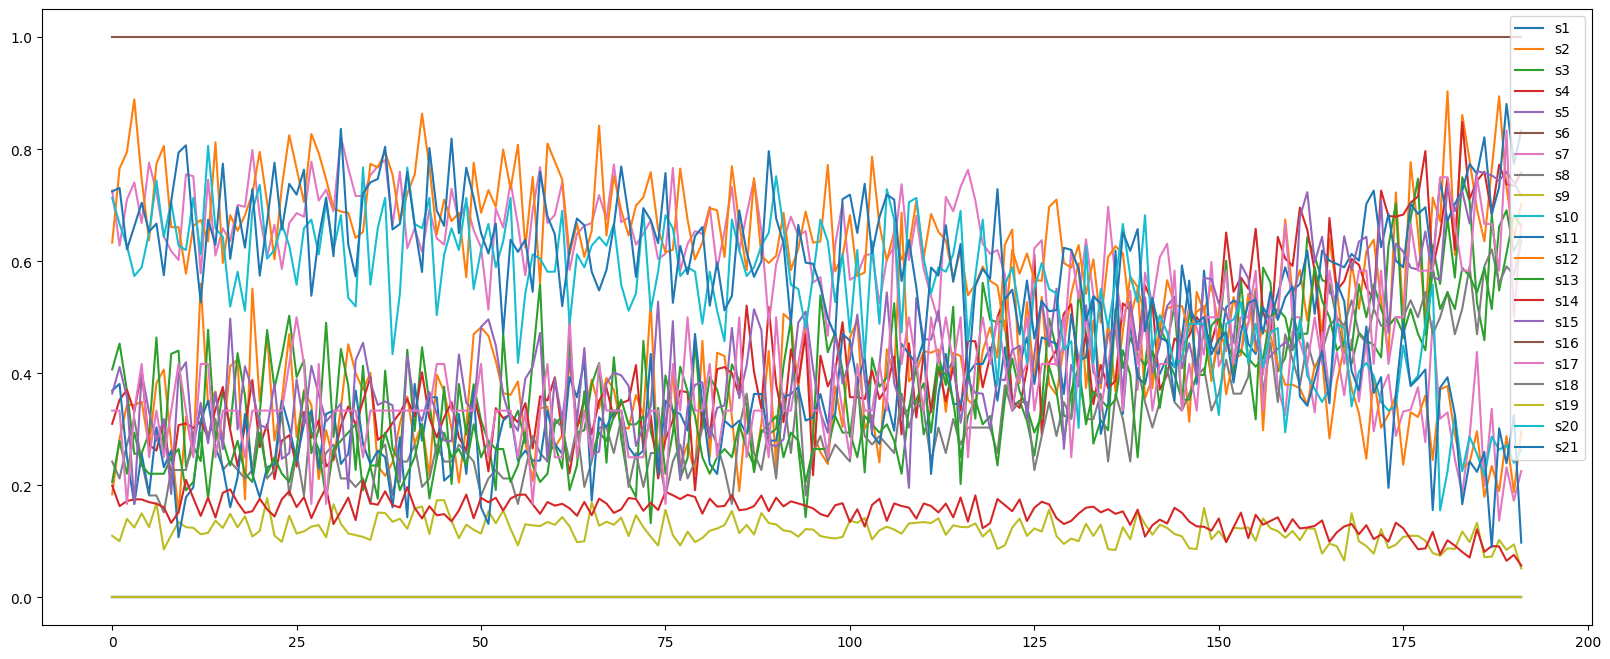

In [ ]:
sensor_cols = cols_names[5:]
train_df[train_df.id==1][sensor_cols].plot(figsize=(20, 8))

In [ ]:
train_df[train_df.id==1][sensor_cols[1]].plot(figsize=(10, 3))

* Sensor 1 values increase when the cycle of number incrceases.
* Sensor 6 values decrease when the cycle of number increases.
* Most other sensors exhibit either an increasing or decreasing trend.


<Axes: >

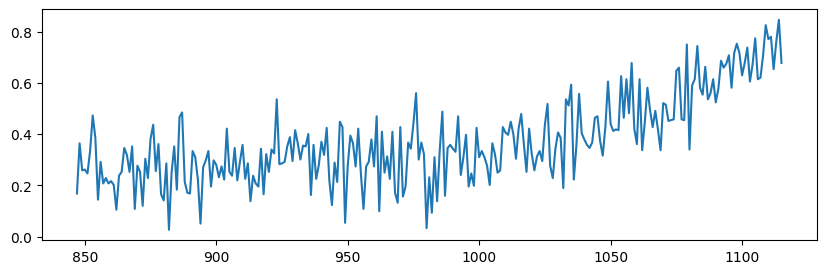

In [ ]:
train_df[train_df.id==5][sensor_cols[1]].plot(figsize=(10, 3))

In [ ]:
train_df[train_df.id==1][sensor_cols[6]].plot(figsize=(10, 3))

We have plotted sensor1 observations for id 1 and id 5.

Both observations have an upward trend with increasing cycles.

<Axes: >

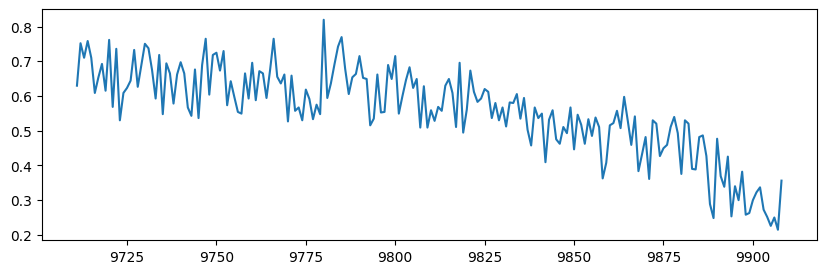

In [ ]:
train_df[train_df.id==50][sensor_cols[6]].plot(figsize=(10, 3))

We have plotted sensor6 observations for id 1 and id 50.

Both observations have a downward trend with increasing cycles.

We can sew that when the sensor values approach a particular value, the aircraft may fail to work soon.

# 5. Generating Input Sequence


In [ ]:
# The sequence length to be used for predictions is as follows:
sequence_length = 50

In [ ]:
# The function to generate sequences (samples, time steps, features) for a particular engine id is as follows:

def sequence_generator(feature_df, seq_length, seq_cols):
    # We will not be using any sequence below seq_length.
    # Convert the DataFrame into a NumPy 2D array.
    feature_array = feature_df[seq_cols].values
    num_elements = feature_array.shape[0]

    # We want to generate sequences of 50 timesteps at a time.
    # Hence, we will iterate over two sets of indices: (0,142),(50,192).
    # For example, id1 has 192 rows, and its sequence_length is equal to 50.
    # 0 50 -> From row 0 to row 50
    # 1 51 -> From row 1 to row 51
    # 2 52 -> From row 2 to row 52
    # ...
    # 141 191 -> From row 111 to 191

    for start, stop in zip(range(0, num_elements-seq_length), range(seq_length, num_elements)):
        yield feature_array[start:stop, :]

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
maternusherold_pred_maintanance_data_path = kagglehub.dataset_download('maternusherold/pred-maintanance-data')

print('Data source import complete.')

# %% [markdown]
# # Introduction.
# The notebook aims to learn building RNN and LSTM networks for time-dependent variables.
# While I was looking to learn building an LSTM like networks for continuous/time-dependent variables, I came across a very nice notebook ([link](https://github.com/Azure/lstms_for_predictive_maintenance/blob/master/Deep%20Learning%20Basics%20for%20Predictive%20Maintenance.ipynb)). In this notebook most of the approach is taken from the mentioned notebook link and credit goes to original authors. <br>
#
# Problem statement: Predict if an engine will fail within a particular cycle, given its history of cycles and sensory data. <br>
#
# * Aircraft are very sensitive to the faults in their engines.
# * Because of this, it is imperative to keep them in good condition for the safety of the passengers.
# * Aircraft are very expensive and so is their maintenance.
# * But at the same time, we do not want to overdo the maintenance aspect.
# * If we do not detect a fault in time, it might become too expensive to maintain/repair the engines, or they might have to be replaced
#
#
# The content of the notebooks are as below.
# 1. importing libs<br>
# 2. Load the Dataset <br>
# 3. Data Preprocessing<br>
#     3.1. Generating the classification target variable<br>
#     3.2. Normalizing the data set<br>
# 4.Exploratory Data Analysis - EDA<br>
# 5. Generating Input Sequence<br>
# 6. RNN Models<br>
#     6.1 Simple RNN [1 Feature] <br>
#     6.2 Simple RNN [25 Features] <br>
#     6.3  Bi-Directional RNN [25 Features] <br>
# 7. Model Building with LSTM <br>
# 8. References
#
# ![image.png](attachment:fe04186a-4eaa-4cc2-9957-123070b8a8a9.png)
# %% [markdown]
# # 1. Importing libs
# %%
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU
# %%
# We will set the seed for reproducibility.
np.random.seed(1234)
PYTHONHASHSEED = 0
# %% [markdown]
# # 2. Load the Dataset
# %%
# Training data where the last cycle is the failure point for the engines
train_df = pd.read_csv('/kaggle/input/pred-maintanance-data/PM_train.txt', sep=" ", header=None)

# Test data where the failure point is not given for the engines
test_df = pd.read_csv('/kaggle/input/pred-maintanance-data/PM_test.txt', sep=" ", header=None)

# We wil print some rows of the train data
train_df.head(100)
# %%
# Let's drop the NAN columns 26 and 27 using the dropna() method.
train_df.dropna(axis=1, inplace=True)
test_df.dropna(axis=1, inplace=True)
# %%
print(len(train_df))
print(len(test_df))
# %%
cols_names = ['id', 'cycle', 'setting1', 'setting2', 'setting3', 's1', 's2', 's3',
                     's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14',
                     's15', 's16', 's17', 's18', 's19', 's20', 's21']

train_df.columns = cols_names
test_df.columns = cols_names

train_df.head(2)
# %%
test_df.head(2)
# %%
# Load the ground truth for the test data, which indicates the remaining useful cycles for the engines

truth_df = pd.read_csv('/kaggle/input/pred-maintanance-data/PM_truth.txt', sep=" ", header=None)
truth_df.head()
# %%
# We wil drop the NAN column
truth_df.dropna(axis=1, inplace=True)
truth_df.head()
# %% [markdown]
# # 3. Data Preprocessing
# We will do the following while preprocessing the training dataset:
#
# 1. Generating the classification target variable
# 2. Normalizing the data set
# %% [markdown]
# ## 3.1 Generating Classification Target Variable
# We will classify the cycles close to breakdown with their respective ids as 1 in the target variable failure_within_w1.
#
# Here, w1 signifies the window_1, which in this case is 30.
#
# **IMP: In this case, during the last cycle the aircraft was in a bad state, and before the last cycle the aircraft indeed required maintenance. here predicting the x number of cycles before the aircraft brake down is very important.
# the number of cycles before the actual breakdown we are referring to it as the window. In this case, the window can be 15, 30, 45 ..etc. it depends upon how early we want to flag the maintenance and the dependency on the accuracy.
# In this case we are assuming window size as 30 (Aim to find if the maintenance requiered before 30 cycles) <br>**
#
# ![image.png](attachment:0faf6c70-801a-4a57-b9f9-bbcf5f7bcf53.png)
# %% [markdown]
# Sort the data set by id and cycles so each engine can have its values sorted and stored in one place. We use the sort_values()
#
# %%
# method and specify which columns are to be considered while sorting using the parameter.

train_df.sort_values(['id','cycle'], inplace=True)
test_df.sort_values(['id','cycle'], inplace=True)
# %% [markdown]
# First, we find the maximum cycles observed for each engine using groupby() and then merge these values for respective engine data using merge().
#
# Then, we calculate the remaining useful life (RUL) by subtracting the current cycle value from the max. For example, a cycle has a total life of 192 cycles, and it has already run 50 cycles; hence, its RUL will be 192-50 = 142.
#
#
# %%
# Extract the maximum number of cycles for each engine id.
rul = pd.DataFrame(train_df.groupby('id')['cycle'].max()).reset_index()

# Name the columns and merge them with the training data.
rul.columns = ['id', 'max']
train_df = train_df.merge(rul, on=['id'], how='left')

# Now subtract the current cycle from the max (maximum number of cycles) to calculate the remaining useful life.
train_df['RUL'] = train_df['max'] - train_df['cycle']

#The RUL is calculated for each id.
train_df[['id','cycle','max','RUL']].head()
# %%
# We

Data source import complete.
20631
13096


,id,cycle,max,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


In [ ]:
# The function to generate labels is as follows:
def label_generator(label_df, seq_length, label):
    # Funtion will return
    # This function will return the following:
    # [[1]
    # [4]
    # [1]
    # [5]
    # [9]
    # ...
    # [200]]
    # Convert the labels into a NumPy 2D array.

    label_array = label_df[label].values
    num_elements = label_array.shape[0]
        # Remove the first label, as the first prediction will be the (seq_length+1)th label.
    return label_array[seq_length:num_elements, :]

Data source import complete.
20631
13096


(15631, 1)

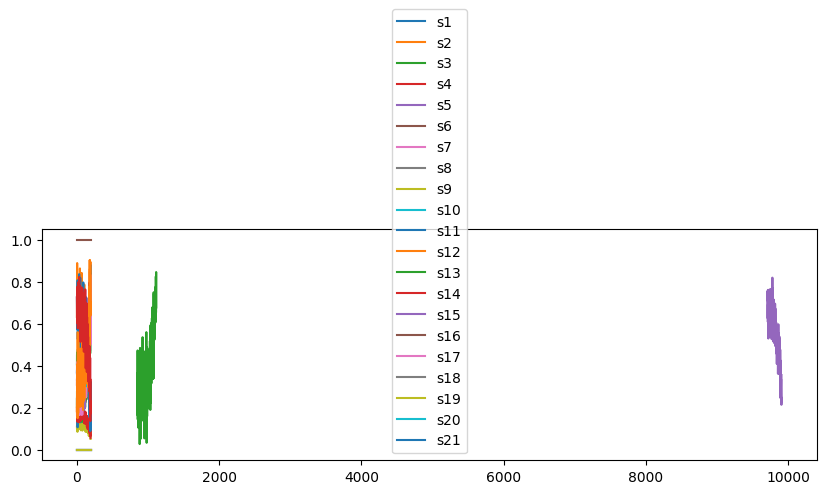

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
maternusherold_pred_maintanance_data_path = kagglehub.dataset_download('maternusherold/pred-maintanance-data')

print('Data source import complete.')

# %% [markdown]
# # Introduction.
# The notebook aims to learn building RNN and LSTM networks for time-dependent variables.
# While I was looking to learn building an LSTM like networks for continuous/time-dependent variables, I came across a very nice notebook ([link](https://github.com/Azure/lstms_for_predictive_maintenance/blob/master/Deep%20Learning%20Basics%20for%20Predictive%20Maintenance.ipynb)). In this notebook most of the approach is taken from the mentioned notebook link and credit goes to original authors. <br>
#
# Problem statement: Predict if an engine will fail within a particular cycle, given its history of cycles and sensory data. <br>
#
# * Aircraft are very sensitive to the faults in their engines.
# * Because of this, it is imperative to keep them in good condition for the safety of the passengers.
# * Aircraft are very expensive and so is their maintenance.
# * But at the same time, we do not want to overdo the maintenance aspect.
# * If we do not detect a fault in time, it might become too expensive to maintain/repair the engines, or they might have to be replaced
#
#
# The content of the notebooks are as below.
# 1. importing libs<br>
# 2. Load the Dataset <br>
# 3. Data Preprocessing<br>
#     3.1. Generating the classification target variable<br>
#     3.2. Normalizing the data set<br>
# 4.Exploratory Data Analysis - EDA<br>
# 5. Generating Input Sequence<br>
# 6. RNN Models<br>
#     6.1 Simple RNN [1 Feature] <br>
#     6.2 Simple RNN [25 Features] <br>
#     6.3  Bi-Directional RNN [25 Features] <br>
# 7. Model Building with LSTM <br>
# 8. References
#
# ![image.png](attachment:fe04186a-4eaa-4cc2-9957-123070b8a8a9.png)
# %% [markdown]
# # 1. Importing libs
# %%
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU
# %%
# We will set the seed for reproducibility.
np.random.seed(1234)
PYTHONHASHSEED = 0
# %% [markdown]
# # 2. Load the Dataset
# %%
# Training data where the last cycle is the failure point for the engines
train_df = pd.read_csv('/kaggle/input/pred-maintanance-data/PM_train.txt', sep=" ", header=None)

# Test data where the failure point is not given for the engines
test_df = pd.read_csv('/kaggle/input/pred-maintanance-data/PM_test.txt', sep=" ", header=None)

# We wil print some rows of the train data
train_df.head(100)
# %%
# Let's drop the NAN columns 26 and 27 using the dropna() method.
train_df.dropna(axis=1, inplace=True)
test_df.dropna(axis=1, inplace=True)
# %%
print(len(train_df))
print(len(test_df))
# %%
cols_names = ['id', 'cycle', 'setting1', 'setting2', 'setting3', 's1', 's2', 's3',
                     's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14',
                     's15', 's16', 's17', 's18', 's19', 's20', 's21']

train_df.columns = cols_names
test_df.columns = cols_names

train_df.head(2)
# %%
test_df.head(2)
# %%
# Load the ground truth for the test data, which indicates the remaining useful cycles for the engines

truth_df = pd.read_csv('/kaggle/input/pred-maintanance-data/PM_truth.txt', sep=" ", header=None)
truth_df.head()
# %%
# We wil drop the NAN column
truth_df.dropna(axis=1, inplace=True)
truth_df.head()
# %% [markdown]
# # 3. Data Preprocessing
# We will do the following while preprocessing the training dataset:
#
# 1. Generating the classification target variable
# 2. Normalizing the data set
# %% [markdown]
# ## 3.1 Generating Classification Target Variable
# We will classify the cycles close to breakdown with their respective ids as 1 in the target variable failure_within_w1.
#
# Here, w1 signifies the window_1, which in this case is 30.
#
# **IMP: In this case, during the last cycle the aircraft was in a bad state, and before the last cycle the aircraft indeed required maintenance. here predicting the x number of cycles before the aircraft brake down is very important.
# the number of cycles before the actual breakdown we are referring to it as the window. In this case, the window can be 15, 30, 45 ..etc. it depends upon how early we want to flag the maintenance and the dependency on the accuracy.
# In this case we are assuming window size as 30 (Aim to find if the maintenance requiered before 30 cycles) <br>**
#
# ![image.png](attachment:0faf6c70-801a-4a57-b9f9-bbcf5f7bcf53.png)
# %% [markdown]
# Sort the data set by id and cycles so each engine can have its values sorted and stored in one place. We use the sort_values()
#
# %%
# method and specify which columns are to be considered while sorting using the parameter.

train_df.sort_values(['id','cycle'], inplace=True)
test_df.sort_values(['id','cycle'], inplace=True)
# %% [markdown]
# First, we find the maximum cycles observed for each engine using groupby() and then merge these values for respective engine data using merge().
#
# Then, we calculate the remaining useful life (RUL) by subtracting the current cycle value from the max. For example, a cycle has a total life of 192 cycles, and it has already run 50 cycles; hence, its RUL will be 192-50 = 142.
#
#
# %%
# Extract the maximum number of cycles for each engine id.
rul = pd.DataFrame(train_df.groupby('id')['cycle'].max()).reset_index()

# Name the columns and merge them with the training data.
rul.columns = ['id', 'max']
train_df = train_df.merge(rul, on=['id'], how='left')

# Now subtract the current cycle from the max (maximum number of cycles) to calculate the remaining useful life.
train_df['RUL'] = train_df['max'] - train_df['cycle']

#The RUL is calculated for each id.
train_df[['id','cycle','max','RUL']].head()
# %%
# We do not need "max" anymore.
train_df.drop('max', axis=1, inplace=True)
# %% [markdown]
# Generate label column for training data
# %%
# We will make a label that indicates whether an engine is going to fail within w1 cycles.
w1 = 30
train_df['failure_within_w1'] = np.where(train_df['RUL'] <= w1, 1, 0 )

# %% [markdown]
# ## 3.2 Normalize Training Dataset
# %%
# Make a separate feature for the normalized value of the cycle column.
train_df['cycle_norm'] = train_df['cycle']

# Using the difference function, we exclude these columns from the normalization process.
cols_normalize = train_df.columns.difference(['id','cycle','RUL','failure_within_w1'])

# MinMax normalization (from 0 to 1) of sensor data
min_max_scaler = preprocessing.MinMaxScaler()
norm_train_df = pd.DataFrame(min_max_scaler.fit_transform(train_df[cols_normalize]),
                             columns=cols_normalize,
                             index=train_df.index)

#Join the normalized and non-normalized data.
join_df = train_df[['id','cycle','RUL','failure_within_w1']].join(norm_train_df)
train_df = join_df.reindex(columns = train_df.columns)

train_df.head()
# %% [markdown]
# Normalize the test data in the same manner that you normalized the training data.
# %%
# We will perform MinMax normalization (from 0 to 1)
test_df['cycle_norm'] = test_df['cycle']

# MinMax normalization (from 0 to 1) of the sensor data only
norm_test_df = pd.DataFrame(min_max_scaler.transform(test_df[cols_normalize]),
                            columns=cols_normalize,
                            index=test_df.index)

#Join the normalized and non-normalized data (it does not have 'RUL' and 'failure_within_w1')
test_join_df = test_df[test_df.columns.difference(cols_normalize)].join(norm_test_df)
test_df = test_join_df.reindex(columns = test_df.columns)
test_df = test_df.reset_index(drop=True)
# %% [markdown]
# Label the test set like we did for the training data.
# %%
# Let's calculate the total RUL by summing up the maximum cycles given in the test set and the
# ground truth additional RUL.
rul = pd.DataFrame(test_df.groupby('id')['cycle'].max()).reset_index()
rul.columns = ['id', 'max']
truth_df.columns = ['additional_rul']

# The respective id can be obtained by adding 1 to the index, as the index starts from 0.
truth_df['id'] = truth_df.index + 1

# Add the max cycles given in the test set and the additional RUL given in the ground truth DataFrame.
truth_df['max'] = rul['max'] + truth_df['additional_rul']
truth_df.drop('additional_rul', axis=1, inplace=True)

# Generate the RUL for the test data.
test_df = test_df.merge(truth_df, on=['id'], how='left')
test_df['RUL'] = test_df['max'] - test_df['cycle']
test_df.drop('max', axis=1, inplace=True)

# Generate the label columns w0 and w1 for the test data.
test_df['failure_within_w1'] = np.where(test_df['RUL'] <= w1, 1, 0 )
test_df.head()
# %% [markdown]
# # 4. Exploratory Data Analysis - EDA
# Let's see how the sensor values change for a particular engine id, say id=1.
#
# %%
sensor_cols = cols_names[5:]
train_df[train_df.id==1][sensor_cols].plot(figsize=(20, 8))
# %%
train_df[train_df.id==1][sensor_cols[1]].plot(figsize=(10, 3))
# %% [markdown]
# * Sensor 1 values increase when the cycle of number incrceases.
# * Sensor 6 values decrease when the cycle of number increases.
# * Most other sensors exhibit either an increasing or decreasing trend.
#
# %%
train_df[train_df.id==5][sensor_cols[1]].plot(figsize=(10, 3))
# %%
train_df[train_df.id==1][sensor_cols[6]].plot(figsize=(10, 3))
# %% [markdown]
# We have plotted sensor1 observations for id 1 and id 5.
#
# Both observations have an upward trend with increasing cycles.
# %%
train_df[train_df.id==50][sensor_cols[6]].plot(figsize=(10, 3))
# %% [markdown]
# We have plotted sensor6 observations for id 1 and id 50.
#
# Both observations have a downward trend with increasing cycles.
#
# We can sew that when the sensor values approach a particular value, the aircraft may fail to work soon.
# %% [markdown]
# # 5. Generating Input Sequence
#
# %%
# The sequence length to be used for predictions is as follows:
sequence_length = 50
# %%
# The function to generate sequences (samples, time steps, features) for a particular engine id is as follows:

def sequence_generator(feature_df, seq_length, seq_cols):
    """
    The function to generate sequences (samples, time steps, features) for a particular engine id is as follows:

    feature_df: The input DataFrame containing the features for each engine.
    seq_length: The desired length of each sequence.
    seq_cols: The columns of the DataFrame to be used as features in the sequence.
    """
    # We will not be using any sequence below seq_length.
    # Convert the DataFrame into a NumPy 2D array.
    feature_array = feature_df[seq_cols].values
    num_elements = feature_array.shape[0]

    # We want to generate sequences of 50 timesteps at a time.
    # Hence, we will iterate over two sets of indices: (0,142),(50,192).
    # For example, id1 has 192 rows, and its sequence_length is equal to 50.
    # 0 50 -> From row 0 to row 50
    # 1 51 -> From row 1 to row 51
    # 2 52 -> From row 2 to row 52
    # ...
    # 141 191 -> From row 111 to 191

    for start, stop in zip(range(0, num_elements-seq_length), range(seq_length, num_elements)):
        yield feature_array[start:stop, :]
# %%
# The function to generate labels is as follows:
def label_generator(label_df, seq_length, label):
    # Funtion will return
    # This function will return the following:
    # [[1]
    # [4]
    # [1]
    # [5]
    # [9]
    # ...
    # [200]]
    # Convert the labels into a NumPy 2D array.

    label_array = label_df[label].values
    num_elements = label_array.shape[0]
        # Remove the first label, as the first prediction will be the (seq_length+1)th label.
    return label_array[seq_length:num_elements, :]
# %%
# Generate sequences for each engine id.
# unique() returns all the unique ids in a list.
# Pick the feature columns.
# The 's2' column represents the sensor readings we're interested in.
seq_gen = (list(sequence_generator(train_df[train_df['id']==id], sequence_length, ['s2']))
           for id in train_df['id'].unique())

# Concatenate the sequences of the different engine ids into one and convert it into a NumPy array [(142, 50, 25), ...] --> [(ntotal, 50, 25)].
seq_set = np.concatenate(list(seq_gen)).astype(np.float32)

# Generate labels [[142,1], [121, 1], [3]] --> [1, 2, 3] (ntotal, 1).
label_gen = [label_generator(train_df[train_df['id']==id], sequence_length, ['failure_within_w1'])
             for id in train_df['id'].unique()]
label_set = np.concatenate(label_gen).astype(np.float32)
label_set.shape

# 6. RNN Models
We will build, train, and evaluate the following models:

* Simple RNN [1 Feature] <br>
* Simple RNN [25 Features] <br>
* Bi-Directional RNN [25 Features] <br>

## 6.1 Simple RNN [1 Feature]

In [ ]:
out_dim = label_set.shape[1] # 1 label/output for one sequence.
features_dim = seq_set.shape[2] # Number of features (1)


print("Features dimension: ", features_dim)
print("Output dimension: ", out_dim)

RNN_fwd = Sequential()

# Add the RNN unit.
# Understand the parameters.
RNN_fwd.add(SimpleRNN(
         input_shape=(sequence_length, features_dim),
         units=1,
         return_sequences=False))
RNN_fwd.add(Dropout(0.2))

RNN_fwd.add(Dense(units=out_dim, activation='sigmoid'))

# Compile the model.
RNN_fwd.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(RNN_fwd.summary())

# Define the path to save the model.
RNN_fwd_path = '/kaggle/working/RNN_fwd.h5'

Features dimension:  1
Output dimension:  1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
import time
epochs = 300
batch_size = 200
start = time.time()

# Fit the network.
RNN_fwd_history = RNN_fwd.fit(seq_set, label_set, epochs=epochs, batch_size=batch_size, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(RNN_fwd_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )
end = time.time()
print("Total time taken for training: ", "{:.2f}".format((end-start)), " secs")


Epoch 1/300


75/75 - 3s - 42ms/step - accuracy: 0.6330 - loss: 0.6745 - val_accuracy: 0.6765 - val_loss: 0.6273
Epoch 2/300


75/75 - 1s - 11ms/step - accuracy: 0.7794 - loss: 0.5587 - val_accuracy: 0.7967 - val_loss: 0.5163
Epoch 3/300


75/75 - 1s - 9ms/step - accuracy: 0.8009 - loss: 0.5273 - val_accuracy: 0.8005 - val_loss: 0.5044
Epoch 4/300


75/75 - 1s - 17ms/step - accuracy: 0.8015 - loss: 0.5226 - val_accuracy: 0.8005 - val_loss: 0.5000
Epoch 5/300


...

75/75 - 1s - 13ms/step - accuracy: 0.8634 - loss: 0.3293 - val_accuracy: 0.8811 - val_loss: 0.2687
Epoch 125/300
75/75 - 1s - 15ms/step - accuracy: 0.8650 - loss: 0.3277 - val_accuracy: 0.8798 - val_loss: 0.2723
Epoch 126/300
75/75 - 1s - 8ms/step - accuracy: 0.8624 - loss: 0.3276 - val_accuracy: 0.8824 - val_loss: 0.2690
Epoch 127/300


75/75 - 1s - 9ms/step - accuracy: 0.8648 - loss: 0.3265 - val_accuracy: 0.8798 - val_loss: 0.2676
Epoch 128/300
75/75 - 1s - 16ms/step - accuracy: 0.8666 - loss: 0.3241 - val_accuracy: 0.8772 - val_loss: 0.2735
Epoch 129/300


75/75 - 1s - 8ms/step - accuracy: 0.8655 - loss: 0.3233 - val_accuracy: 0.8824 - val_loss: 0.2658
Epoch 130/300
75/75 - 1s - 8ms/step - accuracy: 0.8658 - loss: 0.3248 - val_accuracy: 0.8785 - val_loss: 0.2712
Epoch 131/300
75/75 - 1s - 9ms/step - accuracy: 0.8691 - loss: 0.3217 - val_accuracy: 0.8811 - val_loss: 0.2721
Epoch 132/300
75/75 - 1s - 8ms/step - accuracy: 0.8658 - loss: 0.3262 - val_accuracy: 0.8811 - val_loss: 0.2682
Epoch 133/300


75/75 - 1s - 9ms/step - accuracy: 0.8666 - loss: 0.3253 - val_accuracy: 0.8811 - val_loss: 0.2652
Epoch 134/300
75/75 - 1s - 9ms/step - accuracy: 0.8656 - loss: 0.3250 - val_accuracy: 0.8824 - val_loss: 0.2672
Epoch 135/300
75/75 - 1s - 8ms/step - accuracy: 0.8667 - loss: 0.3252 - val_accuracy: 0.8824 - val_loss: 0.2667
Epoch 136/300
75/75 - 1s - 8ms/step - accuracy: 0.8657 - loss: 0.3233 - val_accuracy: 0.8824 - val_loss: 0.2666
Epoch 137/300


75/75 - 1s - 8ms/step - accuracy: 0.8675 - loss: 0.3219 - val_accuracy: 0.8836 - val_loss: 0.2629
Epoch 138/300
75/75 - 2s - 21ms/step - accuracy: 0.8672 - loss: 0.3246 - val_accuracy: 0.8798 - val_loss: 0.2683
Epoch 139/300
75/75 - 1s - 13ms/step - accuracy: 0.8682 - loss: 0.3203 - val_accuracy: 0.8785 - val_loss: 0.2696
Epoch 140/300
75/75 - 1s - 9ms/step - accuracy: 0.8648 - loss: 0.3252 - val_accuracy: 0.8798 - val_loss: 0.2675
Epoch 141/300
75/75 - 1s - 8ms/step - accuracy: 0.8658 - loss: 0.3243 - val_accuracy: 0.8785 - val_loss: 0.2669
Epoch 142/300
75/75 - 1s - 9ms/step - accuracy: 0.8659 - loss: 0.3258 - val_accuracy: 0.8785 - val_loss: 0.2678
Epoch 143/300
75/75 - 1s - 8ms/step - accuracy: 0.8671 - loss: 0.3231 - val_accuracy: 0.8785 - val_loss: 0.2655
Epoch 144/300
75/75 - 1s - 8ms/step - accuracy: 0.8670 - loss: 0.3218 - val_accuracy: 0.8811 - val_loss: 0.2637
Epoch 145/300
75/75 - 1s - 9ms/step - accuracy: 0.8668 - loss: 0.3239 - val_accuracy: 0.8824 - val_loss: 0.2643
Epoc

**Model Evaluation on the Train and Validation Sets**

In [ ]:
# The function for plotting the change in the model’s accuracy on the train and validation sets is as follows:
def plot_model_accuracy(model_name_history, width = 10, height = 10):

  fig_acc = plt.figure(figsize=(width, height))
  plt.plot(model_name_history.history['accuracy'])
  plt.plot(model_name_history.history['val_accuracy'])
  plt.title('model accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train', 'val'], loc='upper left')
  plt.show()

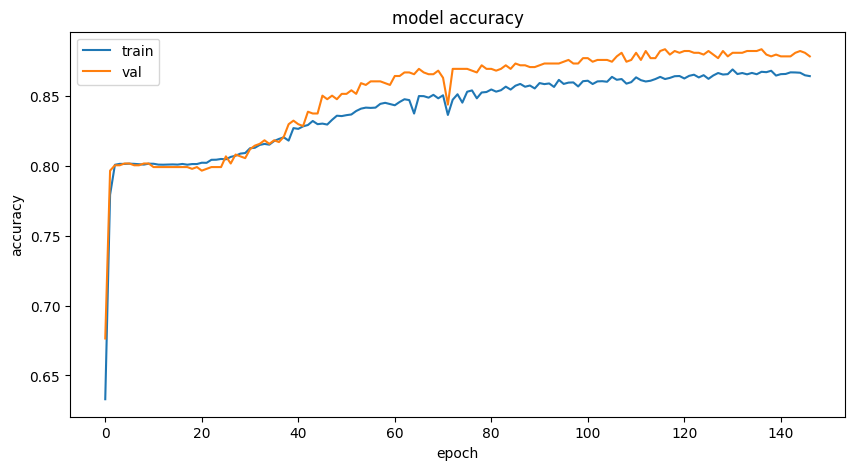

In [ ]:
#Call the function.
plot_model_accuracy(RNN_fwd_history,10,5)

**Training Curve**

In [ ]:
# We will define a function to plot the change in the loss on the train and validation sets.
def plot_training_curve(model_name_history, width = 10, height = 10):
  fig_acc = plt.figure(figsize=(width, height))
  plt.plot(model_name_history.history['loss'])
  plt.plot(model_name_history.history['val_loss'])
  plt.title('model loss')
  plt.ylabel('loss')
  plt.xlabel('epoch')
  plt.legend(['train', 'val'], loc='upper left')
  plt.show()

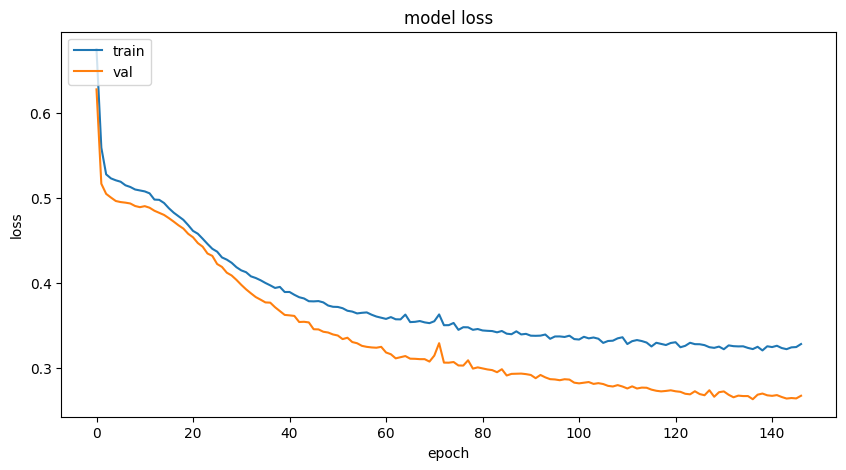

In [ ]:
#Call the function.
plot_training_curve(RNN_fwd_history,10,5)

**Model Evaluation on the Train Set**

In [ ]:
def analyze_model_on_train_set(input_sequence_set, model_name):

  # The training metrics are as follows:
  model_history_scores = model_name.evaluate(input_sequence_set, label_set, verbose=1, batch_size=50)
  print('Train Accurracy: {}'.format(model_history_scores[1]))

  # Make predictions and compute the confusion matrix.
  y_pred = (model_name.predict(input_sequence_set, verbose=1, batch_size=200) > 0.5).astype("int32")
  y_true = label_set

  test_set = pd.DataFrame(y_pred)
  test_set.to_csv('binary_submit_train.csv', index = None)

  print('Confusion matrix\n- x-axis is true labels.\n- y-axis is predicted labels')
  model_cm = confusion_matrix(y_true, y_pred)
  print(model_cm)

  # Compute the precision and recall.
  model_precision = precision_score(y_true, y_pred)
  model_recall = recall_score(y_true, y_pred)
  print( 'Train Precision = ', model_precision, '\n', 'Train Recall = ', model_recall)

# Call the function.
analyze_model_on_train_set(seq_set, RNN_fwd)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8779 - loss: 0.2785
Train Accurracy: 0.8764634132385254
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[12207   324]
 [ 1607  1493]]
Train Precision =  0.82168409466153 
 Train Recall =  0.48161290322580647


**Model evaluation on test set**

In [ ]:
def analyze_model_on_test_set(input_sequence_columns, model_path, width= 10, height=5):
  # We will consider all the last sequences of the test set.
  last_test_seq = [test_df[test_df['id']==id][input_sequence_columns].values[-sequence_length:]
                        for id in test_df['id'].unique() if len(test_df[test_df['id']==id]) >= sequence_length]
  last_test_seq = np.asarray(last_test_seq).astype(np.float32)

  # Get the labels of the test set.
  y_mask = [len(test_df[test_df['id']==id]) >= sequence_length for id in test_df['id'].unique()]
  last_test_label = test_df.groupby('id')['failure_within_w1'].nth(-1)[y_mask].values
  last_test_label = last_test_label.reshape(last_test_label.shape[0],1).astype(np.float32)

  # If the best model weights were saved, load them.
  if os.path.isfile(model_path):
    print("using " + model_path)
    model_estimator = load_model(model_path)

  # Test the metrics.
  start = time.time()
  scores_test = model_estimator.evaluate(last_test_seq, last_test_label, verbose=2)
  end = time.time()
  print("Total time taken for inferencing: ", "{:.2f}".format((end-start)), " secs")

  print('Test Accurracy: {}'.format(scores_test[1]))

  # Make predictions and compute the confusion matrix.
  y_model_estimator_pred_test = (model_estimator.predict(last_test_seq) >0.5).astype("int32")
  y_true_test = last_test_label

  test_set = pd.DataFrame(y_model_estimator_pred_test)
  test_set.to_csv('binary_submit_test.csv', index = None)

  print('Confusion matrix\n- x-axis is true labels.\n- y-axis is predicted labels')
  model_estimator_conf_m = confusion_matrix(y_true_test, y_model_estimator_pred_test)
  print(model_estimator_conf_m)

  # Compute the precision and recall values.
  model_estimator_precision_test = precision_score(y_true_test, y_model_estimator_pred_test)
  model_estimator_recall_test = recall_score(y_true_test, y_model_estimator_pred_test)
  f1_test = 2 * (model_estimator_precision_test * model_estimator_recall_test) / (model_estimator_precision_test + model_estimator_recall_test)
  print( 'Test Precision: ', model_estimator_precision_test, '\n', 'Test Recall: ', model_estimator_recall_test,'\n', 'Test F1-score:', f1_test )

  # Plot the predicted data in blue and the
  # actual data in green to visually verify the accuracy of the model.
  fig_verify = plt.figure(figsize=(10, 5))
  plt.plot(y_model_estimator_pred_test, color="blue")
  plt.plot(y_true_test, color="green")
  plt.title('prediction')
  plt.ylabel('value')
  plt.xlabel('row')
  plt.legend(['predicted', 'actual data'], loc='upper left')
  plt.show()

using /kaggle/working/RNN_fwd.h5
3/3 - 1s - 176ms/step - accuracy: 0.8172 - loss: 0.3499
Total time taken for inferencing:  0.58  secs
Test Accurracy: 0.8172042965888977
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[66  2]
 [15 10]]
Test Precision:  0.8333333333333334 
 Test Recall:  0.4 
 Test F1-score: 0.5405405405405406


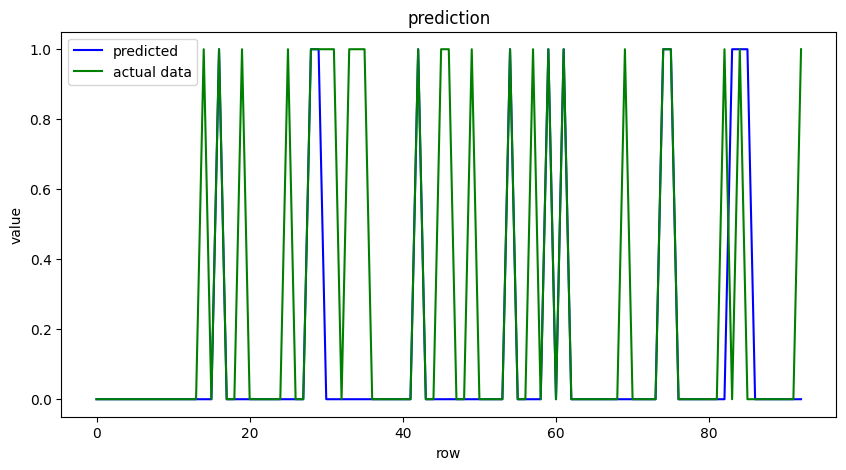

In [ ]:
#Call the function.
analyze_model_on_test_set(["s2"], RNN_fwd_path, 10, 5)

## 6.2 Simple RNN With 25 Features
Let's now consider data from all 21 sensors and 3 settings as well.
This will lead to 25 features in the input sequence set.

In [ ]:
# Pick the feature columns.
sensor_cols = ['s' + str(i) for i in range(1,22)]
sequence_cols_25 = ['setting1', 'setting2', 'setting3', 'cycle_norm']
sequence_cols_25.extend(sensor_cols) # Add the elements of sensor_cols into sequence_cols.

In [ ]:
# Generate sequences for each engine id.
# unique() returns all the unique ids in a list.

seq_gen = (list(sequence_generator(train_df[train_df['id']==id], sequence_length, sequence_cols_25)) #We will take all the features (25).
           for id in train_df['id'].unique())

# Concatenate the sequences of the different engine ids into one and convert it into a NumPy array [(142, 50, 25), ...] --> [(ntotal, 50, 25)].
seq_set_f25 = np.concatenate(list(seq_gen)).astype(np.float32)

#The shape denotes (number of samples, number of time steps, number of features).
seq_set_f25.shape

(15631, 50, 25)

In [ ]:
features_dim = seq_set_f25.shape[2] # number of features (25).
out_dim = label_set.shape[1] # One label (failure_within_w1).

print("Features dimension: ", features_dim)
print("Output dimension: ", out_dim)

RNN_fwd_2 = Sequential()

# Understanding return_sequences and the connection across RNN layers:
# We have to return the sequences from the first layer so the next layer can get the sequence.

RNN_fwd_2.add(SimpleRNN(
         input_shape=(sequence_length, features_dim),
         units=5,
         return_sequences=True))
RNN_fwd_2.add(Dropout(0.2))

RNN_fwd_2.add(SimpleRNN(
          units=3,
          return_sequences=False))
RNN_fwd_2.add(Dropout(0.2))

RNN_fwd_2.add(Dense(units=out_dim, activation='sigmoid'))

# Compile the model.
RNN_fwd_2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(RNN_fwd_2.summary())

# Define the path to save the model.
RNN_fwd_2_path = '/kaggle/working/RNN_fwd_2.h5'

Features dimension:  25
Output dimension:  1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50, 5)          │           155 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186 (744.00 B)

 Trainable params: 186 (744.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
import time
epochs = 200
batch_size = 200
start = time.time()

# Fit the network.
RNN_fwd_2_history = RNN_fwd_2.fit(seq_set_f25, label_set, epochs=epochs, batch_size=batch_size, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(RNN_fwd_2_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )
end = time.time()
print("Total time taken for training: ", "{:.2f}".format((end-start)), " secs")


Epoch 1/200


75/75 - 6s - 81ms/step - accuracy: 0.8075 - loss: 0.4836 - val_accuracy: 0.8363 - val_loss: 0.3928
Epoch 2/200


75/75 - 2s - 21ms/step - accuracy: 0.9176 - loss: 0.3164 - val_accuracy: 0.9182 - val_loss: 0.2682
Epoch 3/200


75/75 - 2s - 22ms/step - accuracy: 0.9300 - loss: 0.2591 - val_accuracy: 0.9233 - val_loss: 0.2451
Epoch 4/200


75/75 - 2s - 21ms/step - accuracy: 0.9337 - loss: 0.2378 - val_accuracy: 0.9233 - val_loss: 0.2324
Epoch 5/200


...

75/75 - 2s - 32ms/step - accuracy: 0.9403 - loss: 0.1629 - val_accuracy: 0.9373 - val_loss: 0.1644
Epoch 24/200


75/75 - 2s - 28ms/step - accuracy: 0.9415 - loss: 0.1632 - val_accuracy: 0.9373 - val_loss: 0.1552
Epoch 25/200
75/75 - 2s - 33ms/step - accuracy: 0.9416 - loss: 0.1666 - val_accuracy: 0.9335 - val_loss: 0.1781
Epoch 26/200
75/75 - 3s - 35ms/step - accuracy: 0.9400 - loss: 0.1629 - val_accuracy: 0.9386 - val_loss: 0.1586
Epoch 27/200
75/75 - 2s - 22ms/step - accuracy: 0.9434 - loss: 0.1583 - val_accuracy: 0.9399 - val_loss: 0.1577
Epoch 28/200
75/75 - 3s - 38ms/step - accuracy: 0.9417 - loss: 0.1617 - val_accuracy: 0.9373 - val_loss: 0.1626
Epoch 29/200
75/75 - 2s - 21ms/step - accuracy: 0.9403 - loss: 0.1627 - val_accuracy: 0.9361 - val_loss: 0.1681
Epoch 30/200
75/75 - 2s - 21ms/step - accuracy: 0.9405 - loss: 0.1612 - val_accuracy: 0.9348 - val_loss: 0.1618
Epoch 31/200


75/75 - 3s - 34ms/step - accuracy: 0.9442 - loss: 0.1551 - val_accuracy: 0.9373 - val_loss: 0.1549
Epoch 32/200


75/75 - 3s - 34ms/step - accuracy: 0.9412 - loss: 0.1602 - val_accuracy: 0.9386 - val_loss: 0.1516
Epoch 33/200
75/75 - 2s - 21ms/step - accuracy: 0.9420 - loss: 0.1571 - val_accuracy: 0.9373 - val_loss: 0.1552
Epoch 34/200


75/75 - 3s - 37ms/step - accuracy: 0.9425 - loss: 0.1564 - val_accuracy: 0.9386 - val_loss: 0.1468
Epoch 35/200
75/75 - 4s - 53ms/step - accuracy: 0.9415 - loss: 0.1550 - val_accuracy: 0.9335 - val_loss: 0.1610
Epoch 36/200
75/75 - 2s - 21ms/step - accuracy: 0.9431 - loss: 0.1565 - val_accuracy: 0.9373 - val_loss: 0.1546
Epoch 37/200
75/75 - 2s - 21ms/step - accuracy: 0.9430 - loss: 0.1537 - val_accuracy: 0.9399 - val_loss: 0.1555
Epoch 38/200
75/75 - 3s - 34ms/step - accuracy: 0.9442 - loss: 0.1533 - val_accuracy: 0.9425 - val_loss: 0.1520
Epoch 39/200
75/75 - 2s - 33ms/step - accuracy: 0.9461 - loss: 0.1508 - val_accuracy: 0.9373 - val_loss: 0.1518
Epoch 40/200
75/75 - 2s - 27ms/step - accuracy: 0.9411 - loss: 0.1545 - val_accuracy: 0.9386 - val_loss: 0.1710
Epoch 41/200
75/75 - 2s - 30ms/step - accuracy: 0.9455 - loss: 0.1481 - val_accuracy: 0.9399 - val_loss: 0.1543
Epoch 42/200
75/75 - 2s - 33ms/step - accuracy: 0.9448 - loss: 0.1505 - val_accuracy: 0.9361 - val_loss: 0.1519
Epoch

**Plot Model Accuracy for the Train and Validation Sets**

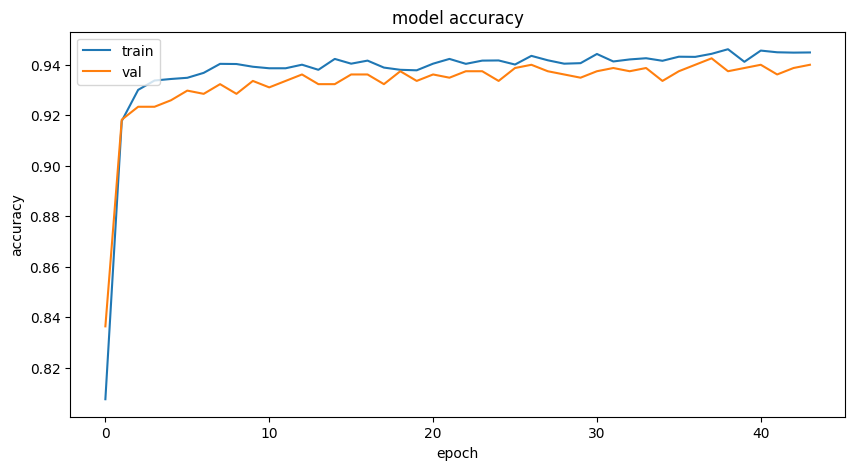

In [ ]:
plot_model_accuracy(RNN_fwd_2_history, 10, 5)

**Training Curve**

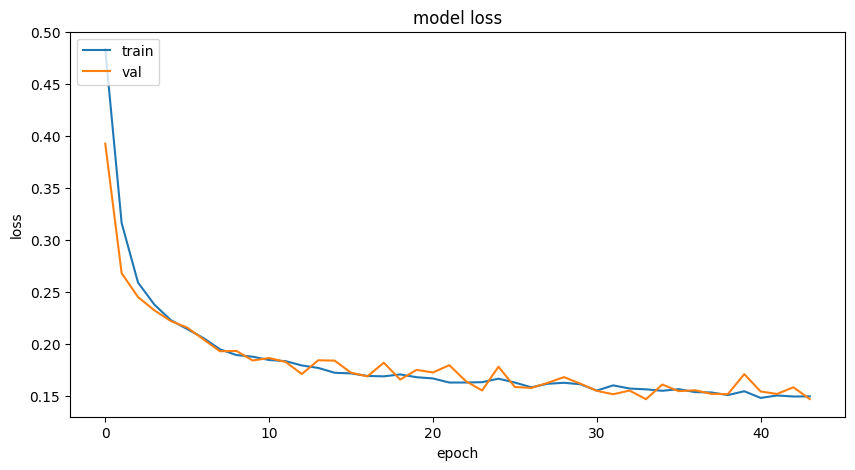

In [ ]:
plot_training_curve(RNN_fwd_2_history,10,5)

**Model Evaluation on Train Set**

In [ ]:
analyze_model_on_train_set(seq_set_f25, RNN_fwd_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9568 - loss: 0.1124
Train Accurracy: 0.9515705704689026


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[12253   278]
 [  479  2621]]
Train Precision =  0.9041048637461193 
 Train Recall =  0.8454838709677419


**Model Evaluation on Test Set**

using /kaggle/working/RNN_fwd_2.h5


3/3 - 1s - 237ms/step - accuracy: 0.9247 - loss: 0.2271
Total time taken for inferencing:  0.78  secs
Test Accurracy: 0.9247311949729919
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[67  1]
 [ 6 19]]
Test Precision:  0.95 
 Test Recall:  0.76 
 Test F1-score: 0.8444444444444444


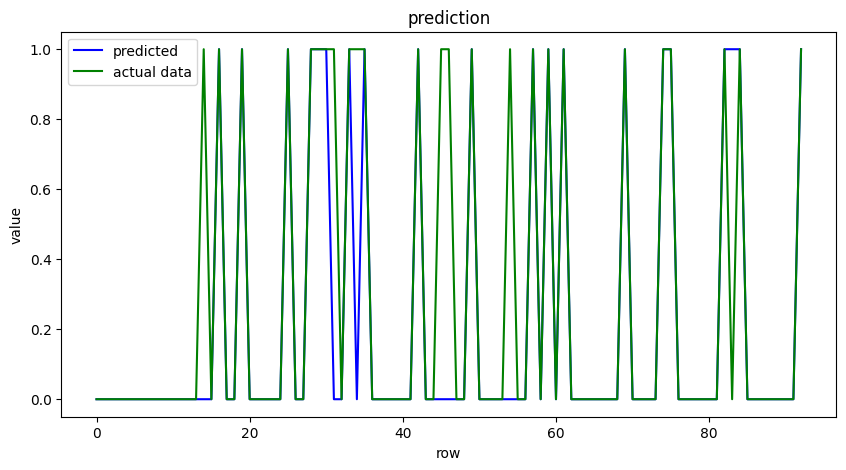

In [ ]:
analyze_model_on_test_set(sequence_cols_25, RNN_fwd_2_path, 10, 5)

## 6.3 Bidirectional RNN

You saw how to build ForwardRNN models with SimpleRNN units.

Let's now create a bidirectional RNN model.


In [ ]:
#Import a bidirectional library.
from tensorflow.keras.layers import Bidirectional

features_dim = seq_set_f25.shape[2] # Number of features (25)
out_dim = label_set.shape[1] # One output for each sequence (failure_within_w1)

print("Features dimension: ", features_dim)
print("Output dimension: ", out_dim)

RNN_bi = Sequential()

# Understanding return_sequences and the connection across RNN layers
# Note that we have to return the sequence from the first layer so the next layer can get the sequence.

RNN_bi.add(Bidirectional( #We need to pass the RNN unit as an argument of the Bidirectional() function.
         SimpleRNN(
         input_shape=(sequence_length, features_dim),
         units=6,
         return_sequences=True)))
RNN_bi.add(Dropout(0.2))

RNN_bi.add(SimpleRNN(
          units=3,
          return_sequences=False))
RNN_bi.add(Dropout(0.2))

RNN_bi.add(Dense(units=out_dim, activation='sigmoid'))

# Compile the model.
RNN_bi.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define the path to save the model.
RNN_bi_path = '/kaggle/working/RNN_bi.h5'

Features dimension:  25
Output dimension:  1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
import time
epochs = 200
batch_size = 200
start = time.time()

# Fit the network
RNN_bi_history = RNN_bi.fit(seq_set_f25, label_set, epochs=epochs, batch_size=batch_size, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(RNN_bi_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )
end = time.time()
print("Total time taken for training: ", "{:.2f}".format((end-start)), " secs")



Epoch 1/200


75/75 - 8s - 106ms/step - accuracy: 0.6675 - loss: 0.6284 - val_accuracy: 0.8018 - val_loss: 0.4657
Epoch 2/200


75/75 - 3s - 35ms/step - accuracy: 0.8064 - loss: 0.4572 - val_accuracy: 0.8798 - val_loss: 0.3447
Epoch 3/200


75/75 - 2s - 31ms/step - accuracy: 0.8847 - loss: 0.3302 - val_accuracy: 0.8811 - val_loss: 0.2859
Epoch 4/200


75/75 - 3s - 34ms/step - accuracy: 0.9084 - loss: 0.2757 - val_accuracy: 0.8887 - val_loss: 0.2652
Epoch 5/200


...

75/75 - 4s - 55ms/step - accuracy: 0.9442 - loss: 0.1587 - val_accuracy: 0.9425 - val_loss: 0.1432
Epoch 20/200
75/75 - 3s - 34ms/step - accuracy: 0.9416 - loss: 0.1612 - val_accuracy: 0.9425 - val_loss: 0.1558
Epoch 21/200


75/75 - 3s - 34ms/step - accuracy: 0.9437 - loss: 0.1562 - val_accuracy: 0.9437 - val_loss: 0.1375
Epoch 22/200


75/75 - 4s - 48ms/step - accuracy: 0.9449 - loss: 0.1550 - val_accuracy: 0.9476 - val_loss: 0.1283
Epoch 23/200
75/75 - 2s - 32ms/step - accuracy: 0.9448 - loss: 0.1540 - val_accuracy: 0.9450 - val_loss: 0.1469
Epoch 24/200
75/75 - 2s - 30ms/step - accuracy: 0.9435 - loss: 0.1529 - val_accuracy: 0.9450 - val_loss: 0.1422
Epoch 25/200
75/75 - 3s - 35ms/step - accuracy: 0.9448 - loss: 0.1540 - val_accuracy: 0.9476 - val_loss: 0.1326
Epoch 26/200
75/75 - 2s - 33ms/step - accuracy: 0.9457 - loss: 0.1508 - val_accuracy: 0.9437 - val_loss: 0.1404
Epoch 27/200
75/75 - 3s - 45ms/step - accuracy: 0.9449 - loss: 0.1522 - val_accuracy: 0.9463 - val_loss: 0.1318
Epoch 28/200
75/75 - 4s - 53ms/step - accuracy: 0.9448 - loss: 0.1497 - val_accuracy: 0.9514 - val_loss: 0.1302
Epoch 29/200
75/75 - 3s - 34ms/step - accuracy: 0.9456 - loss: 0.1495 - val_accuracy: 0.9501 - val_loss: 0.1328
Epoch 30/200
75/75 - 3s - 35ms/step - accuracy: 0.9459 - loss: 0.1477 - val_accuracy: 0.9399 - val_loss: 0.1498
Epoch

75/75 - 3s - 34ms/step - accuracy: 0.9455 - loss: 0.1475 - val_accuracy: 0.9527 - val_loss: 0.1277
Epoch 33/200
75/75 - 2s - 30ms/step - accuracy: 0.9447 - loss: 0.1485 - val_accuracy: 0.9399 - val_loss: 0.1696
Epoch 34/200
75/75 - 2s - 29ms/step - accuracy: 0.9467 - loss: 0.1467 - val_accuracy: 0.9501 - val_loss: 0.1368
Epoch 35/200
75/75 - 2s - 30ms/step - accuracy: 0.9483 - loss: 0.1450 - val_accuracy: 0.9501 - val_loss: 0.1356
Epoch 36/200
75/75 - 3s - 41ms/step - accuracy: 0.9463 - loss: 0.1462 - val_accuracy: 0.9514 - val_loss: 0.1306
Epoch 37/200
75/75 - 3s - 37ms/step - accuracy: 0.9459 - loss: 0.1440 - val_accuracy: 0.9425 - val_loss: 0.1529
Epoch 38/200


75/75 - 5s - 62ms/step - accuracy: 0.9469 - loss: 0.1474 - val_accuracy: 0.9527 - val_loss: 0.1122
Epoch 39/200
75/75 - 2s - 30ms/step - accuracy: 0.9472 - loss: 0.1444 - val_accuracy: 0.9514 - val_loss: 0.1303
Epoch 40/200
75/75 - 3s - 37ms/step - accuracy: 0.9474 - loss: 0.1449 - val_accuracy: 0.9412 - val_loss: 0.1464
Epoch 41/200
75/75 - 3s - 39ms/step - accuracy: 0.9471 - loss: 0.1439 - val_accuracy: 0.9514 - val_loss: 0.1348
Epoch 42/200
75/75 - 2s - 30ms/step - accuracy: 0.9466 - loss: 0.1441 - val_accuracy: 0.9540 - val_loss: 0.1261
Epoch 43/200
75/75 - 2s - 31ms/step - accuracy: 0.9448 - loss: 0.1421 - val_accuracy: 0.9527 - val_loss: 0.1167
Epoch 44/200
75/75 - 2s - 33ms/step - accuracy: 0.9465 - loss: 0.1443 - val_accuracy: 0.9540 - val_loss: 0.1265
Epoch 45/200
75/75 - 3s - 43ms/step - accuracy: 0.9477 - loss: 0.1411 - val_accuracy: 0.9514 - val_loss: 0.1144
Epoch 46/200
75/75 - 4s - 59ms/step - accuracy: 0.9477 - loss: 0.1440 - val_accuracy: 0.9540 - val_loss: 0.1245
Epoch

In [ ]:
#Print the summary of the model.
print(RNN_bi.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 12)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 3)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310 (5.12 KB)

 Trainable params: 436 (1.70 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 874 (3.42 KB)

None


**Plot model accuracy for train and validation set**

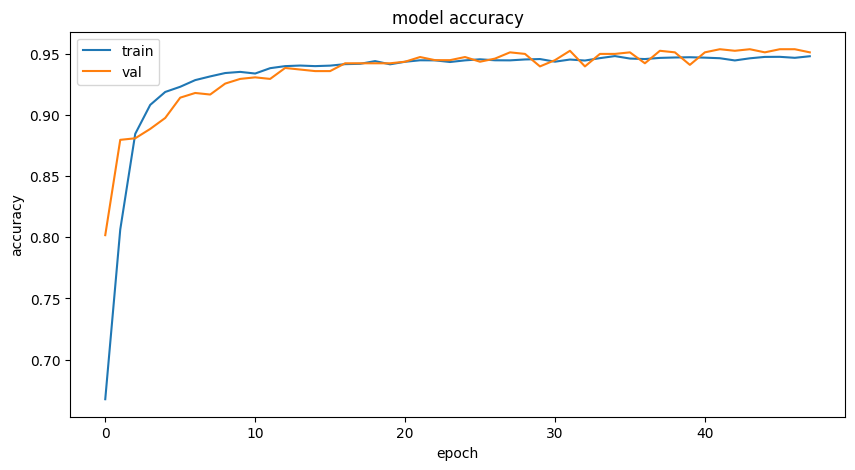

In [ ]:
plot_model_accuracy(RNN_bi_history,10,5)

**Training curve**

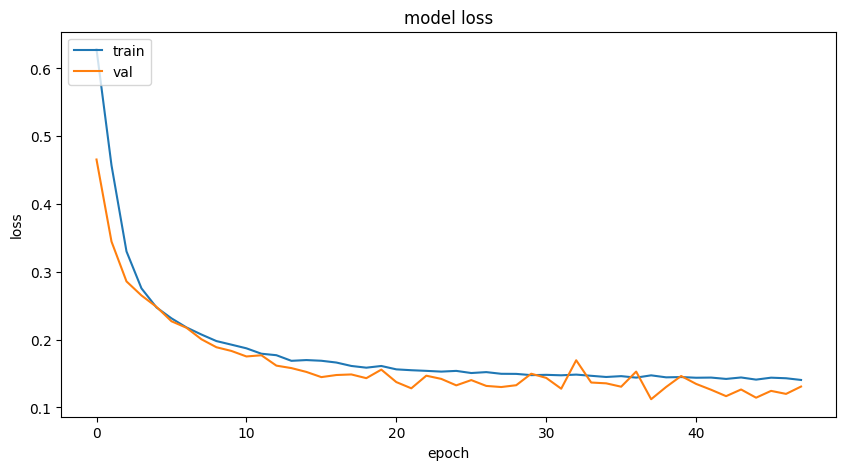

In [ ]:
plot_training_curve(RNN_bi_history,10,5)

**Model Evaluation on train set**

In [ ]:
analyze_model_on_train_set(seq_set_f25, RNN_bi)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9550 - loss: 0.1116
Train Accurracy: 0.9508668780326843


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[12252   279]
 [  489  2611]]
Train Precision =  0.9034602076124567 
 Train Recall =  0.8422580645161291


**Model Evaluation on test set**

In [ ]:
analyze_model_on_test_set(sequence_cols_25, RNN_bi_path,10,5)

### RNN Summary
1. The performance of the RNN with one feature on the test set is worse than that of a more complex RNN.
2. RNN model with increased units with all 25 features achieves better accuracy and other evaluation metrics
3. When we use more than one layer, the previous layer must be set to return_sequences = True.

# 7. Model Building with LSTM

In [ ]:
# Model - (100 LSTM units with 0.2 dropout) +
#         (50 LSTM units with 0.2 dropout) +
#         (dense layer with sigmoid activation)

features_dim = seq_set_f25.shape[2] # number of features
out_dim = label_set.shape[1] # 1 Label (Target variable is failure_within_w1)

print("Features dimension: ", features_dim)
print("Output dimension: ", out_dim)

model = Sequential()

# Understanding of return_sequences and connection across LSTM layers
model.add(LSTM(
         input_shape=(sequence_length, features_dim),
         units=100,
         return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(
          units=50,
          return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=out_dim, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

# Define path to save model
model_path = '/kaggle/working/binary_model.h5'

Features dimension:  25
Output dimension:  1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 100)        │        50,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,651 (315.04 KB)

 Trainable params: 80,651 (315.04 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
import time
epochs = 200
batch_size = 200
start = time.time()

# Fit the network
history = model.fit(seq_set_f25, label_set, epochs=epochs, batch_size=batch_size, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(model_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )
end = time.time()
print("Total time taken for training: ", "{:.2f}".format((end-start)), " secs")


Epoch 1/200


75/75 - 18s - 234ms/step - accuracy: 0.9838 - loss: 0.0402 - val_accuracy: 0.9770 - val_loss: 0.0571
Epoch 2/200


75/75 - 21s - 276ms/step - accuracy: 0.9841 - loss: 0.0356 - val_accuracy: 0.9821 - val_loss: 0.0552
Epoch 3/200


75/75 - 22s - 288ms/step - accuracy: 0.9840 - loss: 0.0382 - val_accuracy: 0.9847 - val_loss: 0.0437
Epoch 4/200


75/75 - 18s - 236ms/step - accuracy: 0.9839 - loss: 0.0380 - val_accuracy: 0.9847 - val_loss: 0.0366
Epoch 5/200
75/75 - 22s - 291ms/step - accuracy: 0.9853 - loss: 0.0350 - val_accuracy: 0.9770 - val_loss: 0.0703
Epoch 6/200
75/75 - 18s - 234ms/step - accuracy: 0.9828 - loss: 0.0388 - val_accuracy: 0.9770 - val_loss: 0.0526
Epoch 7/200
75/75 - 22s - 288ms/step - accuracy: 0.9859 - loss: 0.0351 - val_accuracy: 0.9680 - val_loss: 0.0941
Epoch 8/200
75/75 - 19s - 258ms/step - accuracy: 0.9849 - loss: 0.0349 - val_accuracy: 0.9808 - val_loss: 0.0533
Epoch 9/200
75/75 - 21s - 284ms/step - accuracy: 0.9882 - loss: 0.0301 - val_accuracy: 0.9783 - val_loss: 0.0481
Epoch 10/200
75/75 - 21s - 275ms/step - accuracy: 0.9850 - loss: 0.0348 - val_accuracy: 0.9757 - val_loss: 0.0668
Epoch 11/200
75/75 - 20s - 264ms/step - accuracy: 0.9857 - loss: 0.0348 - val_accuracy: 0.9744 - val_loss: 0.0909
Epoch 12/200
75/75 - 22s - 287ms/step - accuracy: 0.9882 - loss: 0.0307 - val_accuracy: 0.9719 - val_loss:

**Model Evaluation on Validation set**


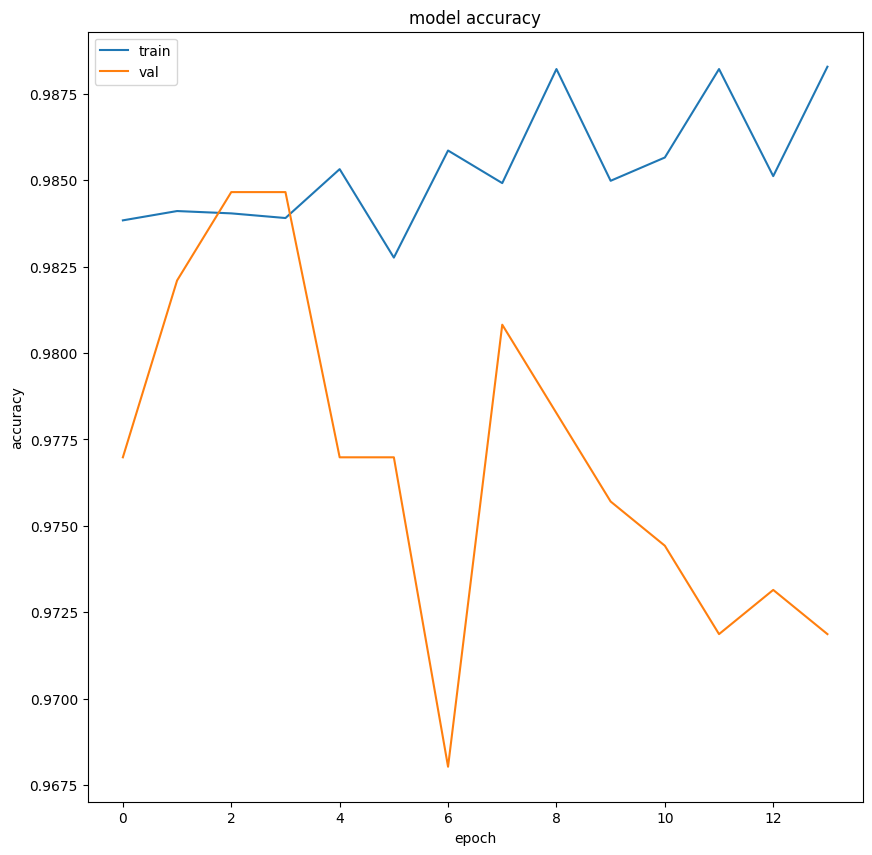

In [ ]:
# Plotting the change in model accuracy on train and val sets
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

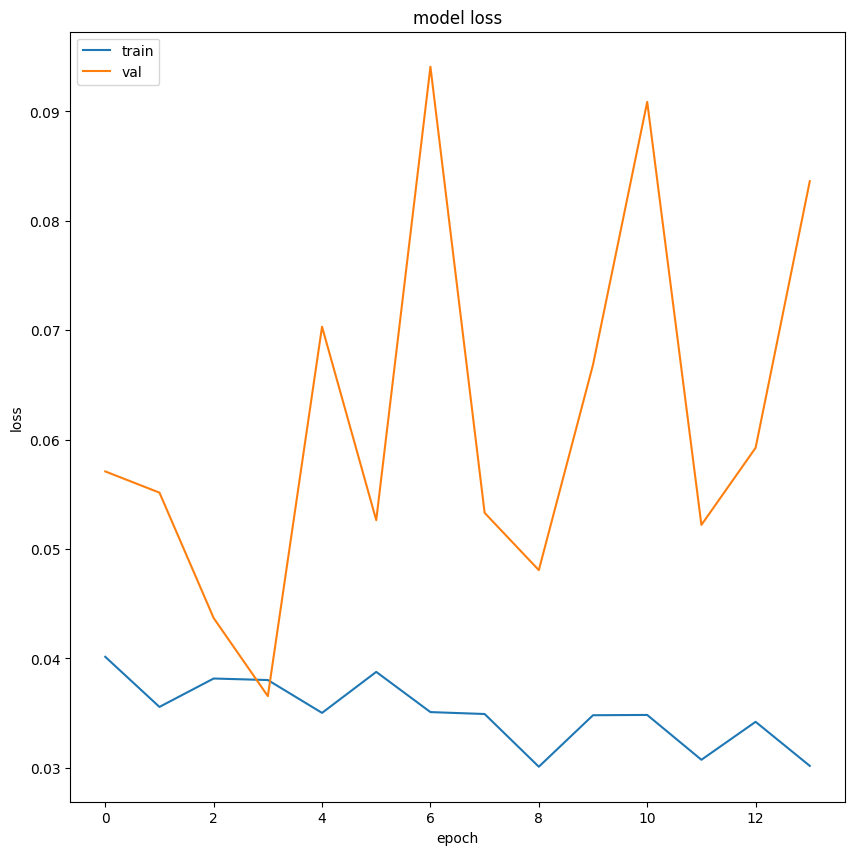

In [ ]:
# Plot model loss for train and test sets
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Training metrics
scores = model.evaluate(seq_set_f25, label_set, verbose=1, batch_size=50)
print('Train Accurracy: {}'.format(scores[1]))

# Make predictions and compute confusion matrix
y_pred = (model.predict(seq_set_f25, verbose=1, batch_size=200) > 0.5).astype("int32")
y_true = label_set

test_set = pd.DataFrame(y_pred)
test_set.to_csv('binary_submit_train.csv', index = None)

print('Confusion matrix\n- x-axis is true labels.\n- y-axis is predicted labels')
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Compute precision and recall
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
print( 'Train Precision = ', precision, '\n', 'Train Recall = ', recall)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.1970 - loss: 0.7117
Train Accurracy: 0.19857974350452423
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[    4 12527]
 [    0  3100]]
Train Precision =  0.19837460805016957 
 Train Recall =  1.0


**Model Evaluation on Test set**

3/3 - 1s - 297ms/step - accuracy: 0.9785 - loss: 0.0540
Total time taken for inferencing:  1.00  secs
Test Accurracy: 0.9784946441650391
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[68  0]
 [ 2 23]]
Test Precision:  1.0 
 Test Recall:  0.92 
 Test F1-score: 0.9583333333333334


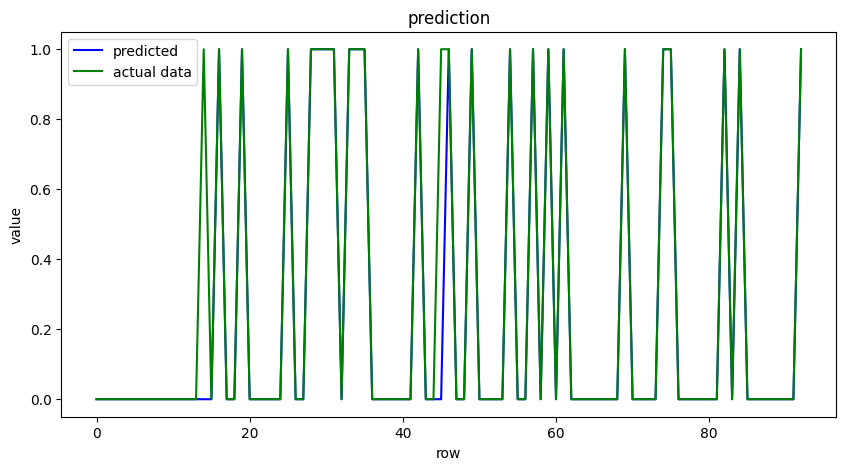

In [ ]:
# Considering all the last sequences of test set
last_test_seq = [test_df[test_df['id']==id][sequence_cols_25].values[-sequence_length:]
                       for id in test_df['id'].unique() if len(test_df[test_df['id']==id]) >= sequence_length]
last_test_seq = np.asarray(last_test_seq).astype(np.float32)

# Get labels of test set
y_mask = [len(test_df[test_df['id']==id]) >= sequence_length for id in test_df['id'].unique()]
last_test_label = test_df.groupby('id')['failure_within_w1'].nth(-1)[y_mask].values
last_test_label = last_test_label.reshape(last_test_label.shape[0],1).astype(np.float32)

# If best model weights were saved then load it
if os.path.isfile(model_path):
    estimator = load_model(model_path)

# Test metrics
start = time.time()
scores_test = estimator.evaluate(last_test_seq, last_test_label, verbose=2)
end = time.time()
print("Total time taken for inferencing: ", "{:.2f}".format((end-start)), " secs")

print('Test Accurracy: {}'.format(scores_test[1]))

# Make predictions and compute confusion matrix
y_pred_test = (estimator.predict(last_test_seq) > 0.5).astype("int32")
y_true_test = last_test_label

test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('binary_submit_test.csv', index = None)

print('Confusion matrix\n- x-axis is true labels.\n- y-axis is predicted labels')
conf_m = confusion_matrix(y_true_test, y_pred_test)
print(conf_m)

# Compute precision and recall
precision_test = precision_score(y_true_test, y_pred_test)
recall_test = recall_score(y_true_test, y_pred_test)
f1_test = 2 * (precision_test * recall_test) / (precision_test + recall_test)
print( 'Test Precision: ', precision_test, '\n', 'Test Recall: ', recall_test,'\n', 'Test F1-score:', f1_test )

# Plot in blue color the predicted data and in green color the
# Actual data to verify visually the accuracy of the model.
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test, color="blue")
plt.plot(y_true_test, color="green")
plt.title('prediction')
plt.ylabel('value')
plt.xlabel('row')
plt.legend(['predicted', 'actual data'], loc='upper left')
plt.show()

# 8. References


- [1] Deep Learning for Predictive Maintenance https://github.com/Azure/lstms_for_predictive_maintenance/blob/master/Deep%20Learning%20Basics%20for%20Predictive%20Maintenance.ipynb
- [2] Predictive Maintenance: Step 2A of 3, train and evaluate regression models https://gallery.cortanaintelligence.com/Experiment/Predictive-Maintenance-Step-2A-of-3-train-and-evaluate-regression-models-2
- [3] A. Saxena and K. Goebel (2008). "Turbofan Engine Degradation Simulation Data Set", NASA Ames Prognostics Data Repository (https://ti.arc.nasa.gov/tech/dash/groups/pcoe/prognostic-data-repository/#turbofan), NASA Ames Research Center, Moffett Field, CA
- [4] Understanding LSTM Networks http://colah.github.io/posts/2015-08-Understanding-LSTMs/


## ******************************************* Happy Learning*******************************